#### environment: !pip -q install torch torchvision einops

## GET, Summer 26 Project-Diffusion

You will be implementing a DDPM on MNIST dataset, with and without classifier free guidance. Before starting, make sure you have a good understanding of class notes. All notations are from this tutorial: https://arxiv.org/abs/2208.11970 . We follow the epsilon-estimation formulation.

#### What's provided:
We have provided a diffusion denoising U-Net, a diffusion scheduler and helper funcionts, visualization code for conditional and unconditional generation.

#### Items you need to complete:
Some functions in this starter code are incomplete. You will complete those functions and upload the completed code (in `.ipynb` format) to Gradescope. We will test your implementation with custom inputs.  
   You are required to complete the following functions:
   1. DDPM epsilon estimation loss (`ddpm_loss_epsilon()`).
   2. DDPM epsilon estimation loss for classifier free guidance (`ddpm_loss_cfg()`).  
   3. DDPM unconditional sampling`sample_unconditional()`
   4. DDPM sampling with classifer free guidance`sample_conditional()`

We also provide the visualization code for the sampling. You need to write a report about CFG sampling when you tune the gamma parameter.

In [ ]:
import math, random, os, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as vutils
from einops import rearrange

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0); np.random.seed(0); random.seed(0)

# Data: MNIST to [-1,1], shape (B,1,28,28)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2, drop_last=True)
num_classes = 10


100%|██████████| 9.91M/9.91M [00:01<00:00, 4.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.0MB/s]


### DDPM with linear scheduler, you only need to run the code, make sure you can understand the code

In [ ]:
# Diffusion schedule
class DiffusionSchedule:
    def __init__(self, T=200, beta_start=1e-4, beta_end=0.02):
        self.T = T
        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1.0 - betas
        alphas_bar = torch.cumprod(alphas, dim=0)

        self.register(betas, alphas, alphas_bar)

    def register(self, betas, alphas, alphas_bar):
        self.betas = betas.to(device)
        self.alphas = alphas.to(device)
        self.alphas_bar = alphas_bar.to(device)
        self.sqrt_alphas = torch.sqrt(self.alphas)
        self.sqrt_one_minus_alphas = torch.sqrt(1.0 - self.alphas)
        self.sqrt_alphas_bar = torch.sqrt(self.alphas_bar)
        self.sqrt_one_minus_alphas_bar = torch.sqrt(1.0 - self.alphas_bar)
        self.one_over_sqrt_alphas = 1.0 / self.sqrt_alphas

    def sample_timesteps(self, bsz):
        return torch.randint(0, self.T, (bsz,), device=device, dtype=torch.long)

    def q_sample(self, x0, t, eps):
        # x_t = sqrt(alphabar_t) * x0 + sqrt(1-alphabar_t) * eps
        s1 = self.sqrt_alphas_bar[t].view(-1,1,1,1)
        s2 = self.sqrt_one_minus_alphas_bar[t].view(-1,1,1,1)
        return s1 * x0 + s2 * eps

    def posterior_mean_variance(self, xt, eps_pred, t):
        # t: (B,), xt: (B,1,28,28), eps_pred: same shape as xt
        alpha_t      = self.alphas[t].view(-1,1,1,1)
        alpha_bar_t  = self.alphas_bar[t].view(-1,1,1,1)

        # compute alpha_bar_{t-1}; define alpha_bar_{-1}=1 for t=0
        t_prev = torch.clamp(t-1, min=0)
        alpha_bar_prev = self.alphas_bar[t_prev].view(-1,1,1,1)
        alpha_bar_prev = torch.where((t==0).view(-1,1,1,1), torch.ones_like(alpha_bar_prev), alpha_bar_prev)

        beta_t = self.betas[t].view(-1,1,1,1)
        # posterior variance (DDPM)
        beta_tilde_t = ((1 - alpha_bar_prev) / (1 - alpha_bar_t)) * beta_t

        # DDPM ε-prediction mean:
        # mu = 1/sqrt(alpha_t) * (xt - ((1 - alpha_t)/sqrt(1 - alpha_bar_t)) * eps_pred)
        mean = (xt - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * eps_pred) / torch.sqrt(alpha_t)

        var = beta_tilde_t
        return mean, var


### Denoising model architecutre, you only need to run the code

In [ ]:
import math, torch, torch.nn as nn, torch.nn.functional as F

# sinusoidal time embedding
def sinusoidal_time_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device).float() / half)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0,1))
    return emb

# Adaptive GroupNorm
class AdaGN(nn.Module):
    def __init__(self, num_channels, cond_dim, groups=8):
        super().__init__()
        self.gn = nn.GroupNorm(groups, num_channels, affine=False)
        self.fc = nn.Linear(cond_dim, num_channels * 2)
        nn.init.zeros_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)
    def forward(self, x, cond):
        h = self.gn(x)
        s, b = self.fc(cond).chunk(2, dim=1)
        s = s.unsqueeze(-1).unsqueeze(-1)
        b = b.unsqueeze(-1).unsqueeze(-1)
        return h * (1 + s) + b

# Residual block with AdaGN
class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, cond_dim, dropout=0.0):
        super().__init__()
        self.in_conv = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.ada1 = AdaGN(c_out, cond_dim)
        self.mid_conv = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.ada2 = AdaGN(c_out, cond_dim)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.out_conv = nn.Conv2d(c_out, c_out, 3, padding=1)
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, cond):
        h = self.in_conv(x)
        h = F.silu(self.ada1(h, cond))
        h = self.mid_conv(h)
        h = F.silu(self.ada2(h, cond))
        h = self.dropout(h)
        h = self.out_conv(h)
        return F.silu(h + self.skip(x))

class Down(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, 3, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Up(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv = nn.Conv2d(c_in, c_out, 3, padding=1)
    def forward(self, x):
        return self.conv(self.up(x))

class SmallUNet(nn.Module):
    """
    Improved Small U-Net without attention.
    28x28 -> 14x14 -> 7x7 -> 14x14 -> 28x28
    """
    def __init__(self, num_classes=10, null_class=True, ch=64, t_dim=128, y_dim=128, dropout=0.0):
        super().__init__()
        self.null_id = num_classes if null_class else None
        n_embed = num_classes + (1 if null_class else 0)
        self.class_embed = nn.Embedding(n_embed, y_dim)
        self.t_dim, self.y_dim = t_dim, y_dim
        cond_dim = t_dim + y_dim

        self.inp = nn.Conv2d(1, ch, 3, padding=1)

        # down path
        self.rb1 = ResBlock(ch, ch, cond_dim, dropout)
        self.down1 = Down(ch, ch*2)
        self.rb2 = ResBlock(ch*2, ch*2, cond_dim, dropout)
        self.down2 = Down(ch*2, ch*4)

        # bottleneck
        self.rb_mid1 = ResBlock(ch*4, ch*4, cond_dim, dropout)
        self.rb_mid2 = ResBlock(ch*4, ch*4, cond_dim, dropout)

        # up path
        self.up1 = Up(ch*4, ch*2)
        self.rb_up1 = ResBlock(ch*2 + ch*2, ch*2, cond_dim, dropout)
        self.up2 = Up(ch*2, ch)
        self.rb_up2 = ResBlock(ch + ch, ch, cond_dim, dropout)

        self.out = nn.Conv2d(ch, 1, 3, padding=1)

        # time/class projections
        self.proj_t = nn.Sequential(nn.Linear(t_dim, t_dim*4), nn.SiLU(), nn.Linear(t_dim*4, t_dim))
        self.proj_y = nn.Sequential(nn.Linear(y_dim, y_dim*4), nn.SiLU(), nn.Linear(y_dim*4, y_dim))

    def forward(self, x, t, y):
        t_emb = self.proj_t(sinusoidal_time_embedding(t, self.t_dim))
        if y is not None:
            y_emb = self.class_embed(y)
        else:
            y_emb = torch.zeros(x.size(0), self.y_dim, device=x.device)
        y_emb = self.proj_y(y_emb)
        cond = torch.cat([t_emb, y_emb], dim=1)

        # encoder
        h0 = self.inp(x)
        h1 = self.rb1(h0, cond)
        h2 = self.down1(h1)
        h3 = self.rb2(h2, cond)
        h4 = self.down2(h3)
        h5 = self.rb_mid1(h4, cond)
        h6 = self.rb_mid2(h5, cond)

        # decoder
        u1 = self.up1(h6)
        u1 = torch.cat([u1, h3], dim=1)
        u1 = self.rb_up1(u1, cond)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = self.rb_up2(u2, cond)

        eps = self.out(u2)
        return eps


### you need to implement the DDPM loss function

In [ ]:
# Losses
sched = DiffusionSchedule(T=200)
net = SmallUNet(num_classes=num_classes, null_class=True, ch=64).to(device)

def ddpm_loss_epsilon(sched, net, x0, y):
    """
    TODO (A): Standard ε-prediction DDPM loss.
      1) sample t ~ Uniform{0..T-1}
      2) sample eps ~ N(0,I)
      3) build x_t = sqrt(alphabar_t) x0 + sqrt(1-alphabar_t) eps (hint: use sched.q_sample)
      4) predict eps_hat = net(x_t, t, y_cond)  (you may use real labels y here)
      5) MSE between eps_hat and eps
    Return: loss (scalar)
    """
    B = x0.shape[0]
    t = sched.sample_timesteps(B)

    # 2) 정규분포를 따르는 노이즈 eps 샘플링
    eps = torch.randn_like(x0)

    # 3) 노이즈가 추가된 x_t 만들기
    x_t = sched.q_sample(x0, t, eps)

    # 4) U-Net을 통해 노이즈 예측
    eps_hat = net(x_t, t, y)

    # 5) 실제 노이즈와 예측 노이즈 간의 MSE Loss 계산
    loss = F.mse_loss(eps_hat, eps)

    return loss



def ddpm_loss_cfg(sched, net, x0, y, null_id):
    """
    TODO (B): CFG training loss (two forward passes).
      Same steps 1-3 as above (ddpm_loss_epsilon), then:
      - eps_hat_cond = net(x_t, t, y)
      - eps_hat_uncond = net(x_t, t, y_null) (unconditional)
      - loss = MSE(eps_hat_cond, eps) + MSE(eps_hat_uncond, eps)
    Return: loss (scalar)
    """
    # 1) Part A와 동일: t 샘플링, 노이즈 샘플링, x_t 생성
    B = x0.shape[0]
    t = sched.sample_timesteps(B)
    eps = torch.randn_like(x0)
    x_t = sched.q_sample(x0, t, eps)

    # 2) 조건부 노이즈 예측 (실제 라벨 y 사용)
    eps_hat_cond = net(x_t, t, y)

    # 3) 무조건부 노이즈 예측 (null_id로 채워진 텐서 사용)
    y_null_tensor = torch.full_like(y, null_id)
    eps_hat_uncond = net(x_t, t, y_null_tensor)

    # 4) 두 경우의 MSE Loss를 합산
    loss = F.mse_loss(eps_hat_cond, eps) + F.mse_loss(eps_hat_uncond, eps)

    return loss


### training, you just need to run the code

In [ ]:
from tqdm import tqdm
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1-self.decay)
    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)
ema = EMA(net, decay=0.999)

In [ ]:
# Train
USE_CFG_LOSS = True
epochs = 10  # feel free to increase
opt = torch.optim.AdamW(net.parameters(), lr=1e-4)

net.train()
for epoch in (range(1, epochs+1)):
    for x, y in tqdm(train_loader):
        x = x.to(device)
        y = y.to(device)
        if USE_CFG_LOSS:
            loss = ddpm_loss_cfg(sched, net, x, y, null_id=net.null_id)
        else:
            loss = ddpm_loss_epsilon(sched, net, x, y)
        # print(loss)

        opt.zero_grad()
        loss.backward()
        opt.step()
        ema.update(net)
    print(f"epoch {epoch}: loss={loss.item():.4f}")

ema.copy_to(net); net.eval()

100%|██████████| 937/937 [02:20<00:00,  6.69it/s]


epoch 1: loss=0.1023


100%|██████████| 937/937 [02:20<00:00,  6.69it/s]


epoch 2: loss=0.0947


100%|██████████| 937/937 [02:20<00:00,  6.69it/s]


...

100%|██████████| 937/937 [02:20<00:00,  6.69it/s]


epoch 9: loss=0.0754


100%|██████████| 937/937 [02:20<00:00,  6.69it/s]


epoch 10: loss=0.0809


SmallUNet(
  (class_embed): Embedding(11, 128)
  (inp): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rb1): ResBlock(
    (in_conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (ada1): AdaGN(
      (gn): GroupNorm(8, 64, eps=1e-05, affine=False)
      (fc): Linear(in_features=256, out_features=128, bias=True)
    )
    (mid_conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (ada2): AdaGN(
      (gn): GroupNorm(8, 64, eps=1e-05, affine=False)
      (fc): Linear(in_features=256, out_features=128, bias=True)
    )
    (dropout): Identity()
    (out_conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Identity()
  )
  (down1): Down(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (rb2): ResBlock(
    (in_conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (ada1): AdaGN(
      (gn): GroupNorm(8, 128, eps=1e-05, affine=False

### Implement the samplers: (you need to implement a few lines of code inside sample_unconditional and sample_conditional)

In [ ]:
# Samplers
@torch.no_grad()
def sample_unconditional(n=64, steps=None):
    """
    TODO (C): Unconditional ancestral DDPM sampling (no guidance).
      Use the unconditional null label at every step.
      Pseudocode:
        x = N(0,I)
        for t in reversed(range(T)):
            use your unet to get eps_hat
            use, x, eps_hat to get mu and var
            if t > 0: x = mu + sqrt(var) * z, z~N(0,1)
            else:     x = mu
        return x.clamp(-1,1)
    """
    net.eval()
    T = sched.T if steps is None else steps
    # 1. 완전한 무작위 노이즈 화면에서 시작 (x_T)
    x = torch.randn(n, 1, 28, 28, device=device)
    # 무조건부 생성이므로 모든 라벨을 null_id로 채움
    y_null = torch.full((n,), net.null_id, device=device, dtype=torch.long)
    # 2. 시간을 T-1부터 0까지 거꾸로 되돌림
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        '''
        your code here
        1. use your unet to get eps_hat (estimated error)
        2. then get mu and var of the previous step, p(x(t-1)|x_t) (hint: sched.posterior_mean_variance())
        '''
        # 3. U-Net으로 현재 화면에 낀 노이즈(eps_hat) 예측
        eps_hat = net(x, t, y_null)

        # 4. 이전 단계 p(x_{t-1} | x_t)로 가기 위한 평균(mu)과 분산(var) 계산
        mu, var = sched.posterior_mean_variance(x, eps_hat, t)

        # 5. 한 걸음씩 노이즈를 벗겨내며 x 갱신 (Langevin dynamics)
        if ti > 0:
            x = mu + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mu
            # 최종 이미지가 픽셀 범위 [-1, 1] 안에 예쁘게 들어가도록 잘라줌
    return x.clamp(-1,1)


@torch.no_grad()
def sample_conditional(label, gamma=3.0, n=64, steps=None):
    """
    TODO (D): Conditional sampling with classifier-free guidance.
    """
    net.eval()
    T = sched.T if steps is None else steps
    # 1. 완전한 무작위 노이즈에서 시작
    x = torch.randn(n, 1, 28, 28, device=device)
    # 조건부 생성을 위한 실제 라벨(y_lab)과 무조건부 생성을 위한 가짜 라벨(y_null) 준비
    y_lab  = torch.full((n,), int(label), device=device, dtype=torch.long)
    y_null = torch.full((n,), net.null_id, device=device, dtype=torch.long)

    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        '''
        your code here
        1. use your unet to get eps_c, eps_u (estimated error), you should inference twice for both conditional and unconditional
        2. get eps_hat by following CFG weighting: (1.0 + gamma) * eps_c - gamma * eps_u
        3. then get mu and var of the previous step, p(x(t-1)|x_t) (hint: sched.posterior_mean_variance())
        '''
        # 1) U-Net을 두 번 호출하여 각각 조건부/무조건부 노이즈 예측
        eps_c = net(x, t, y_lab)
        eps_u = net(x, t, y_null)

        # 2) CFG 공식을 적용하여 최종 eps_hat 계산
        eps_hat = (1.0 + gamma) * eps_c - gamma * eps_u

        # 3) 이전 단계로 가기 위한 평균과 분산 계산
        mu, var = sched.posterior_mean_variance(x, eps_hat, t)

        # 4) 한 걸음씩 노이즈를 벗겨내며 x 갱신
        if ti > 0:
            x = mu + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mu
    return x.clamp(-1,1)


In [ ]:
# Helpers to visualize
def show_grid(x, nrow=8, title=''):
    x = (x.clamp(-1,1) + 1) * 0.5  # to [0,1]
    grid = vutils.make_grid(x, nrow=nrow)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,8))
    plt.axis('off')
    if title: plt.title(title)
    plt.imshow(grid.permute(1,2,0).cpu())
    plt.show()


### Unconditional Generation

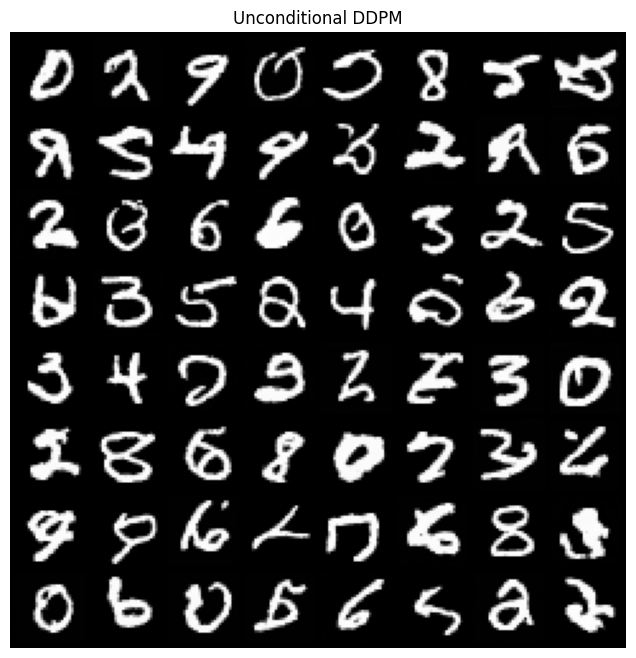

In [ ]:
# Unconditional samples
x_un = sample_unconditional(n=64)
show_grid(x_un, title='Unconditional DDPM')

### Conditional Generation with CFG
Tune this gamma and analyze what different gammas represent. Write a report about this with gamma = [-1, 0, 1, 2, 3, 4, 5]. Show generated images with different gamma and explain the images.

Generating samples with gamma = -1...


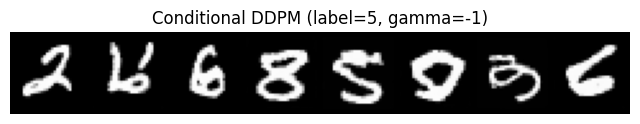

Generating samples with gamma = 0...


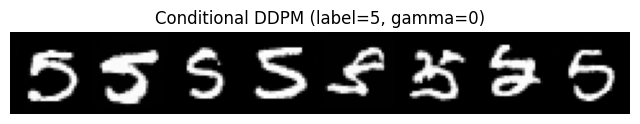

Generating samples with gamma = 1...


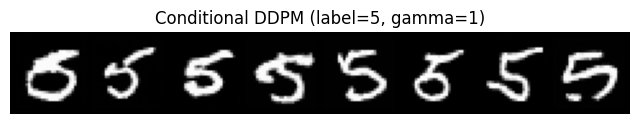

Generating samples with gamma = 2...


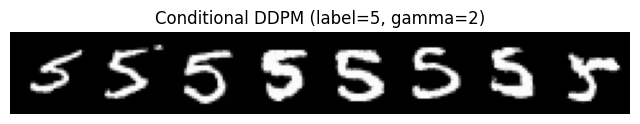

Generating samples with gamma = 3...


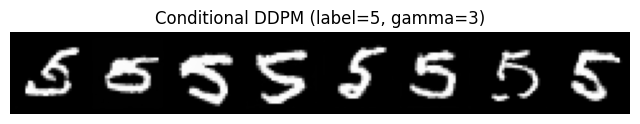

Generating samples with gamma = 4...


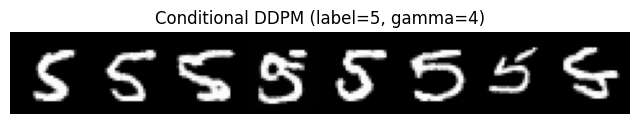

Generating samples with gamma = 5...


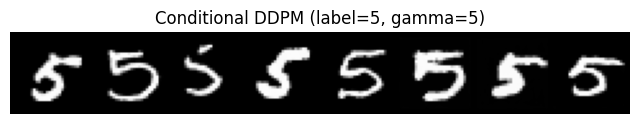

In [ ]:
target_label = 5 # 테스트할 숫자 라벨
gammas = [-1, 0, 1, 2, 3, 4, 5]

for g in gammas:
    print(f"Generating samples with gamma = {g}...")
    # 우리가 만든 조건부 샘플러 호출 (빠른 확인을 위해 n=8, 1줄만 출력)
    samples = sample_conditional(label=target_label, gamma=g, n=8)
    show_grid(samples, nrow=8, title=f'Conditional DDPM (label={target_label}, gamma={g})')

### Code the exploratory parts below

Perturbation 결과


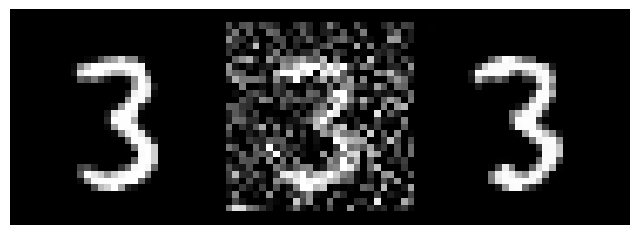

In [ ]:
# 1. Perturbation (노이즈 주입 후 복원)
net.eval()

# 데이터로더에서 원본 이미지(x0) 1장 꺼내오기
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

# t=100 시점 설정 후 노이즈(eps) 원샷 주입
t_start = 100
t_tensor = torch.full((1,), t_start, device=device, dtype=torch.long)
eps = torch.randn_like(x0)
x_t = sched.q_sample(x0, t_tensor, eps)

# 시각화를 위해 노이즈 낀 이미지 잠시 저장
noisy_img = x_t.clone()

# 무조건부(Unconditional)로 t=100부터 0까지 복원
x = x_t
y_null = torch.full((1,), net.null_id, device=device, dtype=torch.long)

with torch.no_grad():
    for ti in reversed(range(t_start)):
        t_curr = torch.full((1,), ti, device=device, dtype=torch.long)

        eps_hat = net(x, t_curr, y_null)
        mu, var = sched.posterior_mean_variance(x, eps_hat, t_curr)

        if ti > 0:
            x = mu + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mu

# 결과 시각화 (원본 -> 노이즈 -> 복원)
print("Perturbation 결과")
show_grid(torch.cat([x0, noisy_img, x.clamp(-1,1)]), nrow=3)

Inpainting 결과


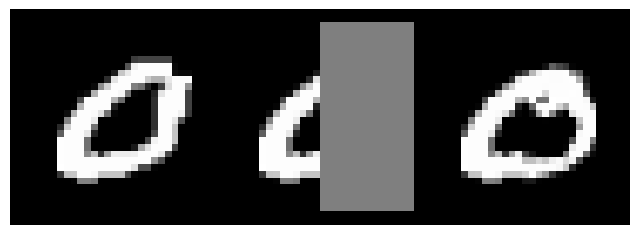

In [ ]:
# 2. Hole filling / Inpainting (빈칸 채우기)
net.eval()

# 원본 이미지 1장 꺼내오기
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

# 마스크 만들기 (왼쪽 절반=1(살림), 오른쪽 절반=0(지움))
mask = torch.ones_like(x0)
mask[:, :, :, 14:] = 0

# 완전한 무작위 노이즈에서 시작
x = torch.randn_like(x0)
y_null = torch.full((1,), net.null_id, device=device, dtype=torch.long)

with torch.no_grad():
    for ti in reversed(range(sched.T)):
        t_curr = torch.full((1,), ti, device=device, dtype=torch.long)

        # 1) 모델이 상상해서 그린 전체 이미지(x_pred)
        eps_hat = net(x, t_curr, y_null)
        mu, var = sched.posterior_mean_variance(x, eps_hat, t_curr)
        x_pred = mu + torch.sqrt(var) * torch.randn_like(x) if ti > 0 else mu

        # 2) 진짜 원본(x0)의 왼쪽 절반에 현재 시간(ti-1)에 맞는 노이즈를 덮어씌움
        if ti > 0:
            noise = torch.randn_like(x0)
            t_prev = torch.full((1,), ti-1, device=device, dtype=torch.long)
            x_known = sched.q_sample(x0, t_prev, noise)
        else:
            x_known = x0

        # 3) 마스크를 이용해 결합: 왼쪽은 진짜(x_known), 오른쪽은 상상(x_pred)
        x = mask * x_known + (1 - mask) * x_pred

# 결과 시각화 (원본 -> 반쪽 잘린 이미지 -> 복원)
masked_x0 = x0 * mask
print("Inpainting 결과")
show_grid(torch.cat([x0, masked_x0, x.clamp(-1,1)]), nrow=3)

In [ ]:
# =====================================================================
# 1. 마스크 비율(0.3, 0.5, 0.7)에 따른 복구 결과 비교
# =====================================================================
def inpaint_with_mask_ratio(x0, ratio):
    mask = torch.ones_like(x0)
    split_idx = int(28 * ratio) # 가로 28픽셀 중 ratio만큼만 남김
    mask[:, :, :, split_idx:] = 0
    
    x = torch.randn_like(x0)
    y_null = torch.full((1,), net.null_id, device=device, dtype=torch.long)
    
    with torch.no_grad():
        for ti in reversed(range(sched.T)):
            t_curr = torch.full((1,), ti, device=device, dtype=torch.long)
            
            eps_hat = net(x, t_curr, y_null)
            mu, var = sched.posterior_mean_variance(x, eps_hat, t_curr)
            x_pred = mu + torch.sqrt(var) * torch.randn_like(x) if ti > 0 else mu
            
            if ti > 0:
                noise = torch.randn_like(x0)
                t_prev = torch.full((1,), ti-1, device=device, dtype=torch.long)
                x_known = sched.q_sample(x0, t_prev, noise)
            else:
                x_known = x0
                
            x = mask * x_known + (1 - mask) * x_pred
            
    return mask * x0, x.clamp(-1, 1)

ratios = [0.3, 0.5, 0.7]
results_ratios = []

for r in ratios:
    masked_img, restored_img = inpaint_with_mask_ratio(x0, r)
    results_ratios.extend([x0, masked_img, restored_img])

print("==== 1. 마스크 비율 비교 (0.3 / 0.5 / 0.7) ====")
print("각 행렬: 원본 -> 마스크된 이미지 -> 복원된 이미지")
show_grid(torch.cat(results_ratios), nrow=3)


# =====================================================================
# 2. Good part(살려둘 부분)에 노이즈화 유무에 따른 복구 결과 비교
# =====================================================================
def inpaint_with_noise_condition(x0, add_noise_to_known=True):
    mask = torch.ones_like(x0)
    mask[:, :, :, 14:] = 0 # 0.5 비율 고정
    
    x = torch.randn_like(x0)
    y_null = torch.full((1,), net.null_id, device=device, dtype=torch.long)
    
    with torch.no_grad():
        for ti in reversed(range(sched.T)):
            t_curr = torch.full((1,), ti, device=device, dtype=torch.long)
            
            eps_hat = net(x, t_curr, y_null)
            mu, var = sched.posterior_mean_variance(x, eps_hat, t_curr)
            x_pred = mu + torch.sqrt(var) * torch.randn_like(x) if ti > 0 else mu
            
            # 노이즈를 추가할지 안 할지 결정하는 핵심 부분!
            if add_noise_to_known and ti > 0:
                noise = torch.randn_like(x0)
                t_prev = torch.full((1,), ti-1, device=device, dtype=torch.long)
                x_known = sched.q_sample(x0, t_prev, noise)
            else:
                # 노이즈화 안함: 매 스텝마다 그냥 쨍한 원본을 그대로 덮어씌움
                x_known = x0
                
            x = mask * x_known + (1 - mask) * x_pred
            
    return mask * x0, x.clamp(-1, 1)

masked_img, restored_with_noise = inpaint_with_noise_condition(x0, add_noise_to_known=True)
_, restored_without_noise = inpaint_with_noise_condition(x0, add_noise_to_known=False)

print("\\n==== 2. Good part 노이즈화 유무 비교 ====")
print("왼쪽부터: 원본 -> 반쪽 이미지 -> 복원(노이즈 추가 O) -> 복원(노이즈 추가 X)")
show_grid(torch.cat([x0, masked_img, restored_with_noise, restored_without_noise]), nrow=4)
